In [31]:
pip install yfinance

In [32]:
import yfinance as yf

In [33]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [34]:
stock = "GOOG"
google_data = yf.download(stock, start, end)

/tmp/ipython-input-2891900888.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google_data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [35]:
google_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2005-10-10,7.684660,7.787816,7.647555,7.750462,223723439
2005-10-11,7.572106,7.734135,7.541431,7.683671,342984790
2005-10-12,7.445203,7.599070,7.396470,7.549842,373643277
2005-10-13,7.357881,7.470682,7.190656,7.470682,424292413
2005-10-14,7.325721,7.426898,7.236668,7.418734,342041267


In [36]:
google_data.shape

(5032, 5)

In [37]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5032.000000,5032.000000,5032.000000,5032.000000,5.032000e+03
mean,55.399569,55.968061,54.806894,55.370784,9.296177e+07
std,52.980738,53.542149,52.387179,52.932004,1.170295e+08
min,6.368386,6.663504,6.117550,6.493805,1.584340e+05
25%,14.198936,14.328373,14.060034,14.212912,2.545100e+07
50%,32.693272,32.986764,32.377209,32.611831,4.323874e+07
75%,78.207939,79.145758,77.294058,78.416243,1.150697e+08
max,255.240005,256.700012,252.067993,254.779999,1.650833e+09


In [38]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5032 entries, 2005-10-10 to 2025-10-09
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5032 non-null   float64
 1   (High, GOOG)    5032 non-null   float64
 2   (Low, GOOG)     5032 non-null   float64
 3   (Open, GOOG)    5032 non-null   float64
 4   (Volume, GOOG)  5032 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.9 KB


In [39]:
google_data.isna().sum()

,,0
Price,Ticker,
Close,GOOG,0
High,GOOG,0
Low,GOOG,0
Open,GOOG,0
Volume,GOOG,0


In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Google data')

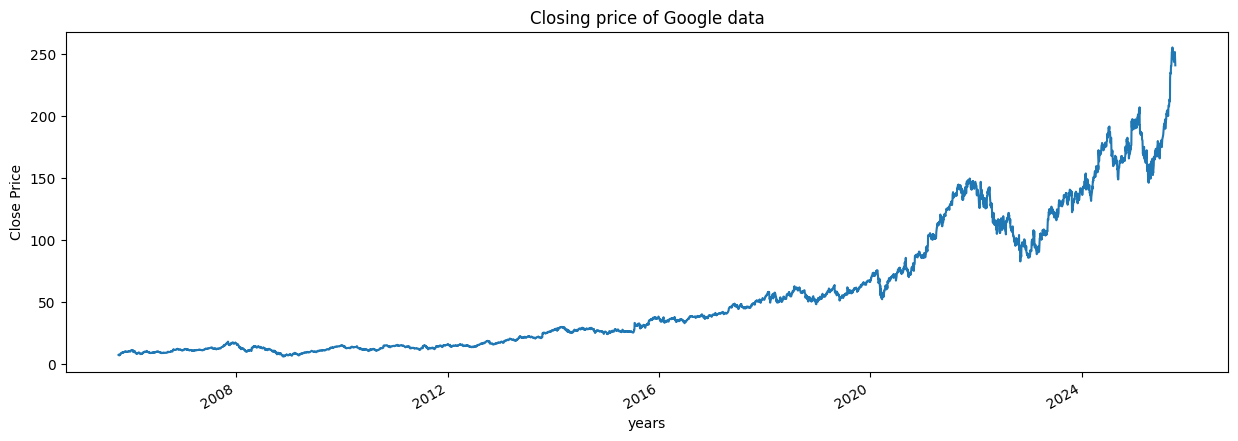

In [41]:
plt.figure(figsize = (15,5))
google_data[('Close', 'GOOG')].plot()
plt.xlabel("years")
plt.ylabel("Close Price")
plt.title("Closing price of Google data")

In [42]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")


In [43]:
google_data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

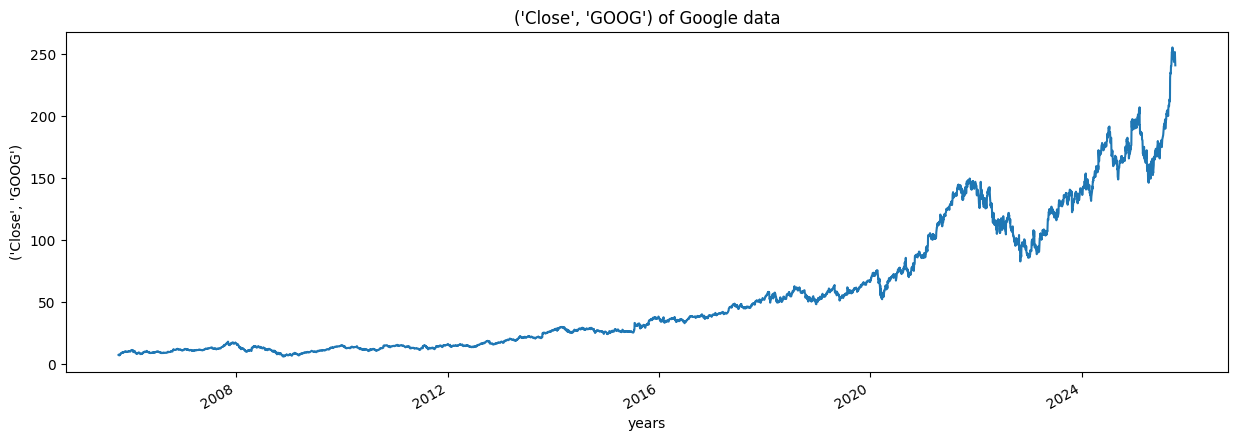

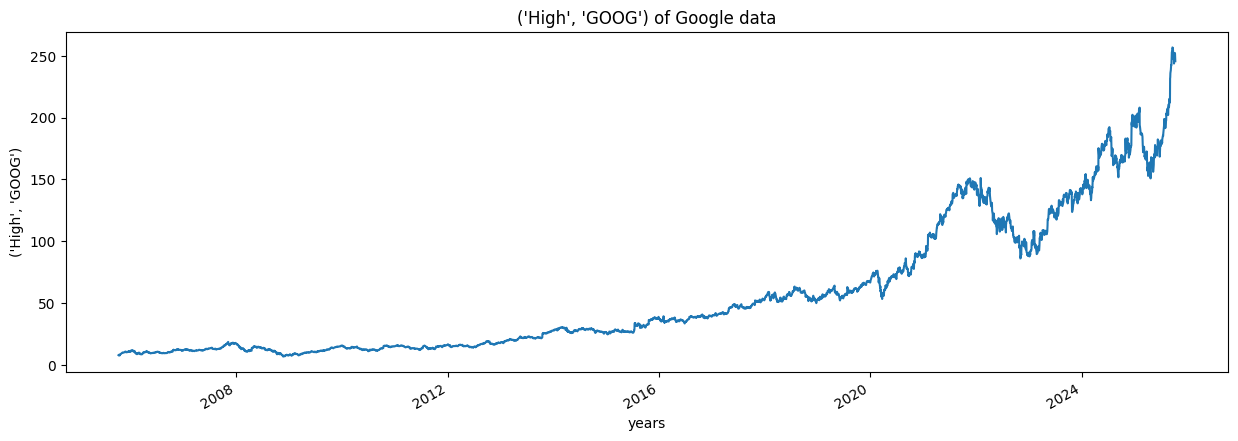

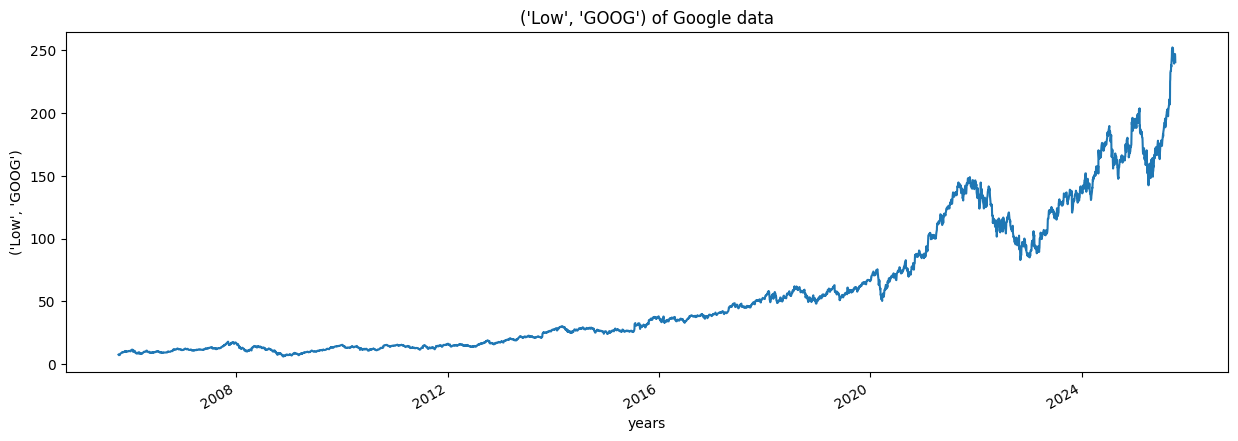

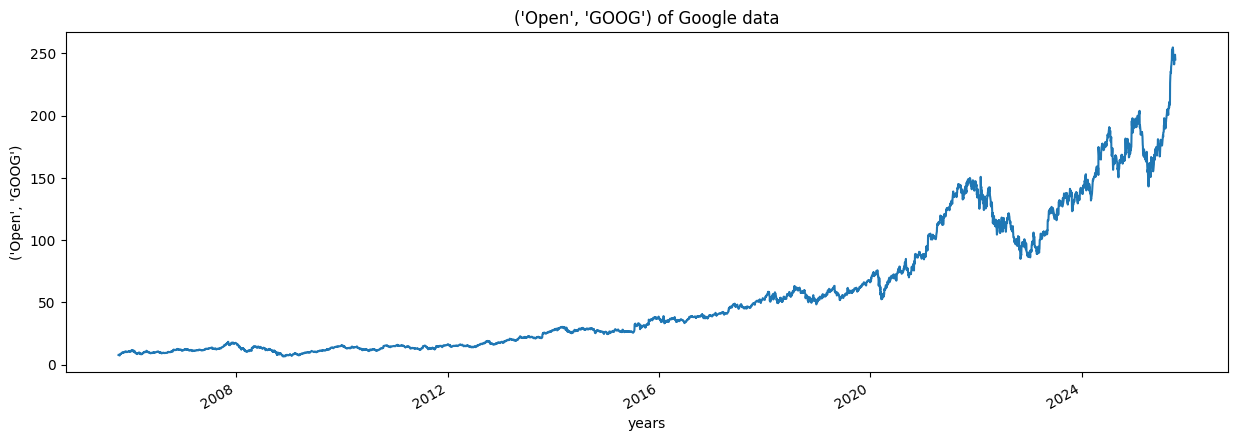

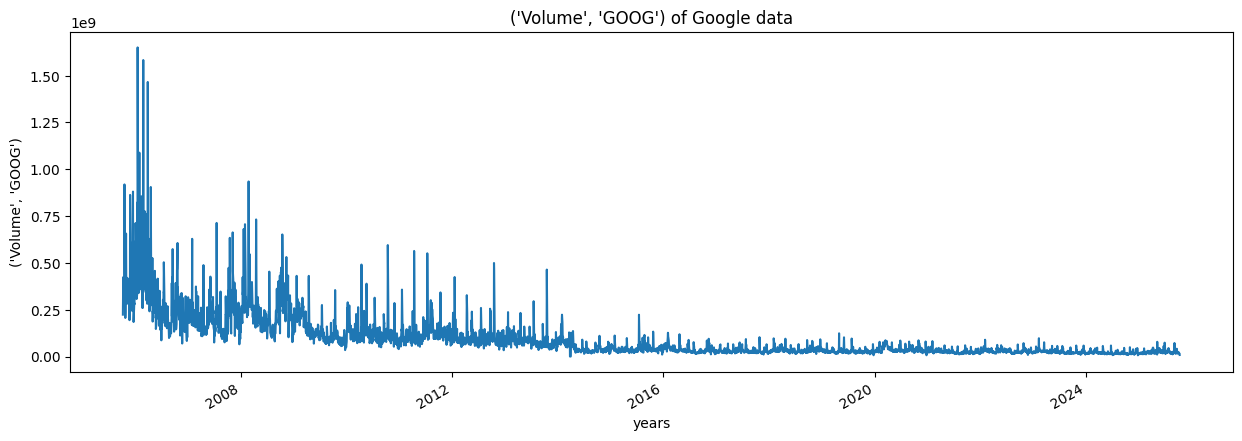

In [44]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)

In [45]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [46]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [47]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [48]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [49]:
for i in range(2004,2025):
    print(i,list(google_data.index.year).count(i))

2004 0
2005 58
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252


In [50]:
google_data['MA_for_250_days'] = google_data[('Close', 'GOOG')].rolling(250).mean()

In [51]:
google_data['MA_for_250_days'][0:250].tail()

,MA_for_250_days
Date,
2006-09-29,NaN
2006-10-02,NaN
2006-10-03,NaN
2006-10-04,NaN
2006-10-05,9.683796


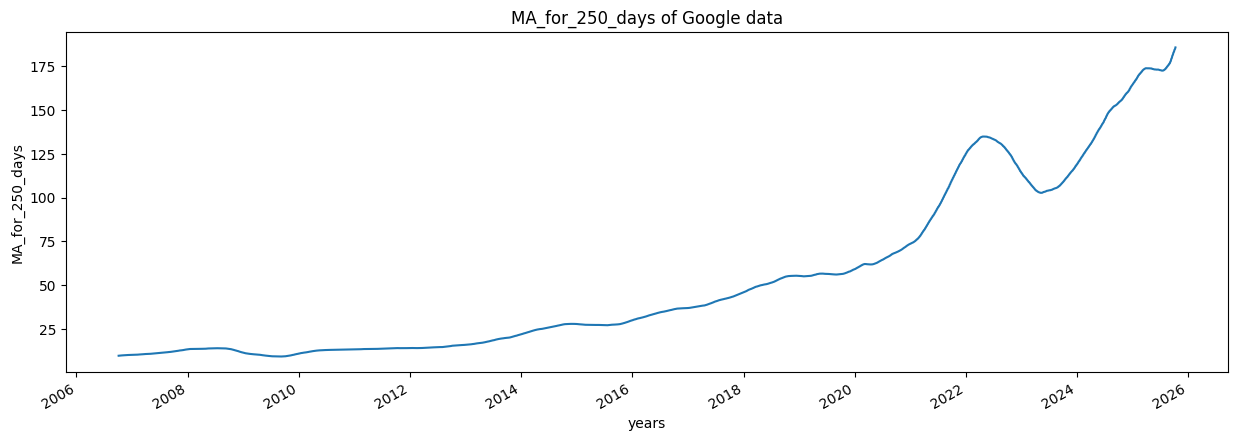

In [52]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

In [55]:
google_data['MA_for_250_days'] = google_data[('Close', 'GOOG')].rolling(250).mean()

In [57]:
google_data.head(2)

Price,Close,High,Low,Open,Volume,MA_for_250_days
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,
Date,,,,,,
2005-10-10,7.684660,7.787816,7.647555,7.750462,223723439,NaN
2005-10-11,7.572106,7.734135,7.541431,7.683671,342984790,NaN


In [59]:
google_data.loc[:, [('Close', 'GOOG')]].assign(MA_for_250_days=google_data['MA_for_250_days'])


Price,Close,MA_for_250_days
Ticker,GOOG,
Date,,
2005-10-10,7.684660,NaN
2005-10-11,7.572106,NaN
2005-10-12,7.445203,NaN
2005-10-13,7.357881,NaN
2005-10-14,7.325721,NaN
...,...,...
2025-10-03,246.449997,184.458170
2025-10-06,251.509995,184.792908


In [62]:
google_data.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in google_data.columns]


In [64]:
google_data.columns

Index(['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG',
       'MA_for_250_days_'],
      dtype='object')

In [65]:
print(google_data.columns.tolist())


['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG', 'MA_for_250_days_']


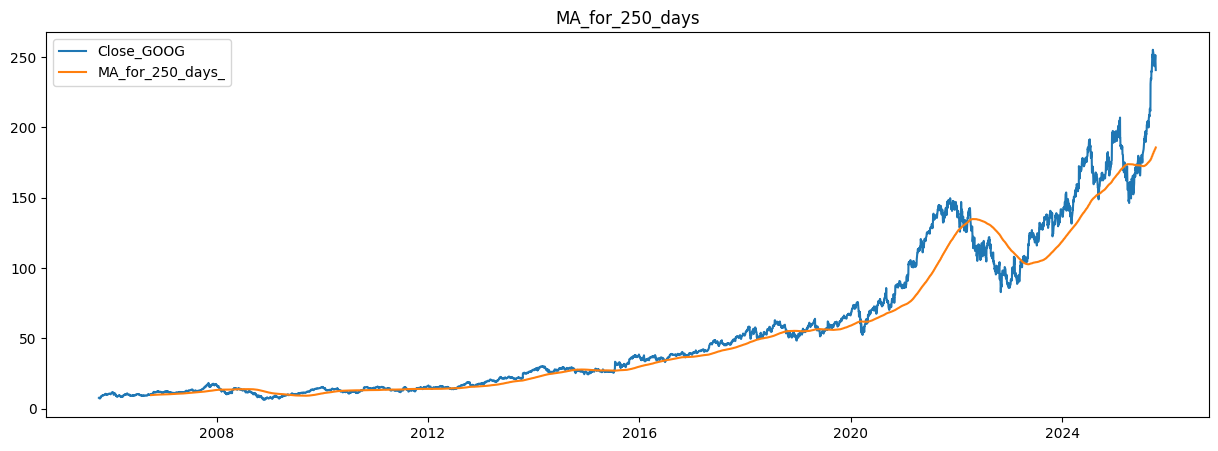

In [70]:
plot_graph((15,5), google_data[['Close_GOOG', 'MA_for_250_days_']], 'MA_for_250_days')


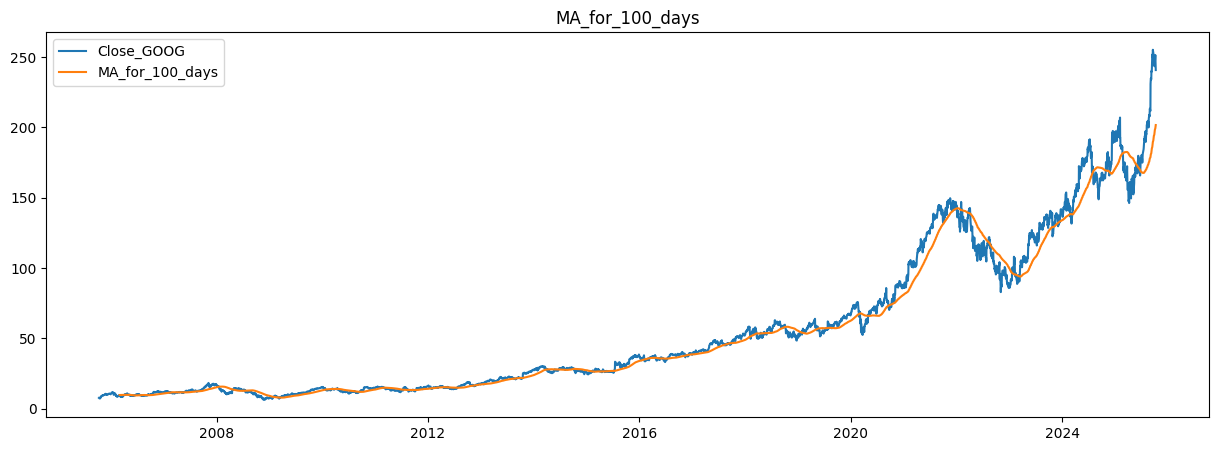

In [75]:
google_data['MA_for_100_days'] = google_data['Close_GOOG'].rolling(100).mean()
plot_graph((15,5), google_data[['Close_GOOG', 'MA_for_100_days']], 'MA_for_100_days')


In [78]:
google_data['percentage_change_cp'] = google_data['Close_GOOG'].pct_change()
google_data[['Close_GOOG', 'percentage_change_cp']].head()


,Close_GOOG,percentage_change_cp
Date,,
2005-10-10,7.684660,NaN
2005-10-11,7.572106,-0.014647
2005-10-12,7.445203,-0.016759
2005-10-13,7.357881,-0.011729
2005-10-14,7.325721,-0.004371


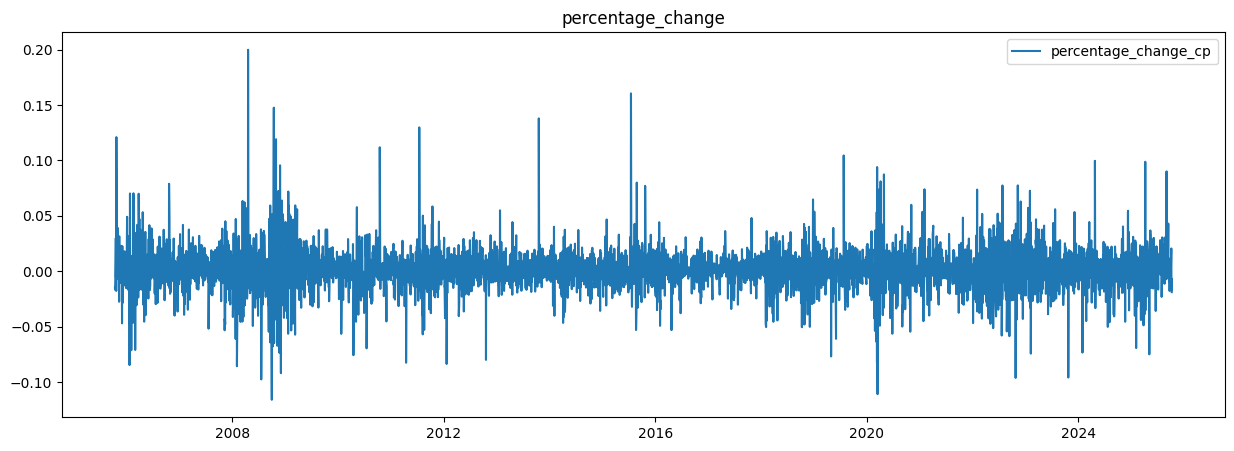

In [81]:
plot_graph((15,5), google_data[['percentage_change_cp']], 'percentage_change')


In [85]:
Adj_close_price = google_data[['Close_GOOG']]


In [87]:
print(google_data.columns.tolist())


['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG', 'MA_for_250_days_', 'MA_for_100_days', 'percentage_change_cp']


In [86]:
max(Adj_close_price.values),min(Adj_close_price.values)

(array([255.24000549]), array([6.36838579]))

In [88]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.00528897],
       [0.00483671],
       [0.0043268 ],
       ...,
       [0.96741292],
       [0.96070264],
       [0.94205849]])

In [89]:
len(scaled_data)

5032

In [90]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [91]:
x_data[0],y_data[0]

(array([[0.00528897],
        [0.00483671],
        [0.0043268 ],
        [0.00397592],
        [0.0038467 ],
        [0.00472737],
        [0.00455641],
        [0.00509515],
        [0.00454845],
        [0.00819636],
        [0.0090661 ],
        [0.00889315],
        [0.009741  ],
        [0.00950445],
        [0.01001237],
        [0.01140096],
        [0.0121206 ],
        [0.01215042],
        [0.01277365],
        [0.01321895],
        [0.01367618],
        [0.01316627],
        [0.01209773],
        [0.01328554],
        [0.01321597],
        [0.01386901],
        [0.01345452],
        [0.0139863 ],
        [0.01451311],
        [0.01419106],
        [0.01510056],
        [0.01580728],
        [0.01644244],
        [0.01701496],
        [0.01650405],
        [0.01452206],
        [0.01465823],
        [0.01557071],
        [0.01592954],
        [0.01475167],
        [0.01462146],
        [0.01458965],
        [0.01522878],
        [0.01508466],
        [0.0154236 ],
        [0

In [92]:

int(len(x_data)*0.7)

3452

In [93]:
4908-100-int(len(x_data)*0.7)

1356

In [94]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [95]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3452, 100, 1)
(3452, 1)
(1480, 100, 1)
(1480, 1)


In [96]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [97]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [98]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [99]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 2.2271e-04
Epoch 2/2
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 3.9467e-05


In [100]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [101]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [102]:
predictions

array([[0.23580824],
       [0.23548199],
       [0.23403098],
       ...,
       [0.84824854],
       [0.8462743 ],
       [0.8410244 ]], dtype=float32)

In [103]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 65.05436],
       [ 64.97317],
       [ 64.61205],
       ...,
       [217.47337],
       [216.98204],
       [215.67549]], dtype=float32)

In [104]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 65.32596588],
       [ 64.70967102],
       [ 64.62525177],
       ...,
       [247.13000488],
       [245.46000671],
       [240.82000732]])

In [105]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))

In [106]:
rmse

np.float64(9.388263697725698)

In [107]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2019-11-19,65.325966,65.054359
2019-11-20,64.709671,64.973167
2019-11-21,64.625252,64.612053
2019-11-22,64.326790,64.318390
2019-11-25,64.890450,64.066566


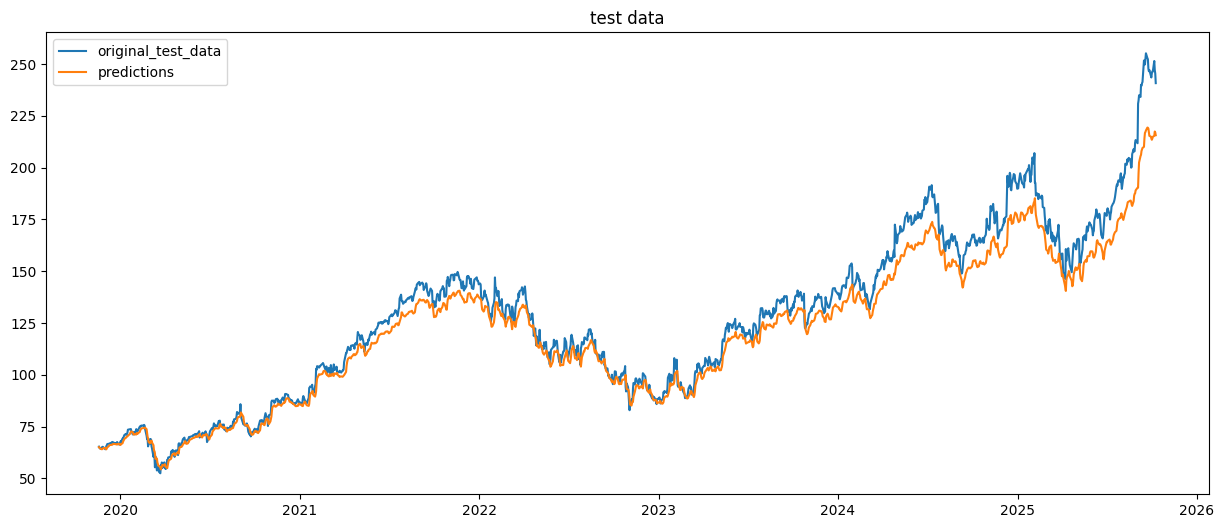

In [108]:
plot_graph((15,6), ploting_data, 'test data')

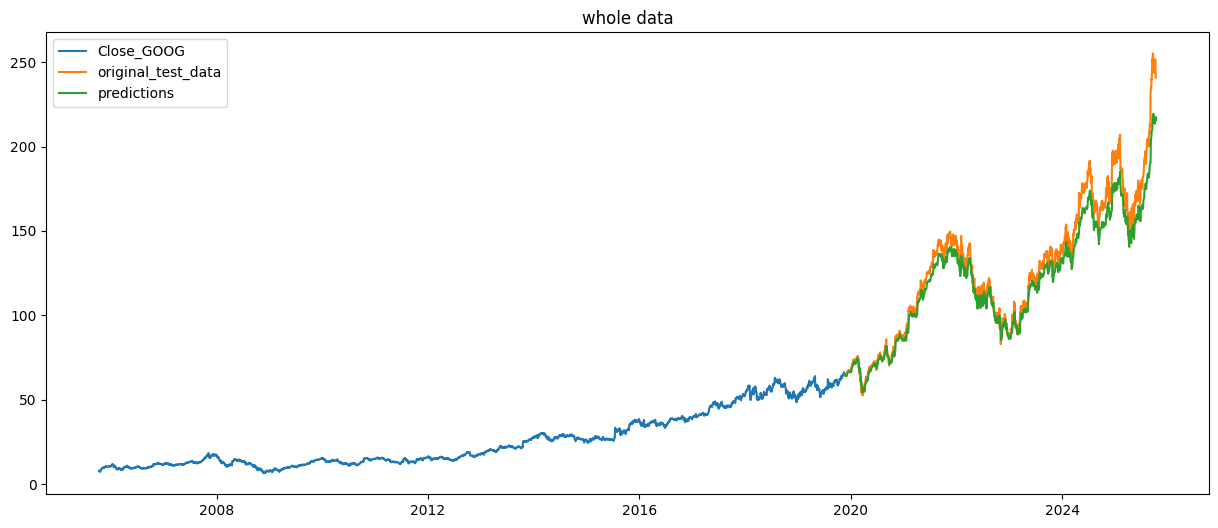

In [109]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [111]:
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
model.save('/content/drive/MyDrive/Latest_stock_price_model.keras')


Mounted at /content/drive


In [110]:
model.save("Latest_stock_price_model.keras")